In [3]:
import pandas as pd

biometric_files = [
    'api_data_aadhar_biometric/api_data_aadhar_biometric_0_500000.csv',
    'api_data_aadhar_biometric/api_data_aadhar_biometric_500000_1000000.csv',
    'api_data_aadhar_biometric/api_data_aadhar_biometric_1000000_1500000.csv',
    'api_data_aadhar_biometric/api_data_aadhar_biometric_1500000_1861108.csv'
]

demographic_files = [
    'api_data_aadhar_demographic/api_data_aadhar_demographic_0_500000.csv',
    'api_data_aadhar_demographic/api_data_aadhar_demographic_500000_1000000.csv',
    'api_data_aadhar_demographic/api_data_aadhar_demographic_1000000_1500000.csv',
    'api_data_aadhar_demographic/api_data_aadhar_demographic_1500000_2000000.csv',
    'api_data_aadhar_demographic/api_data_aadhar_demographic_2000000_2071700.csv'
]

enrolment_files = [
    'api_data_aadhar_enrolment/api_data_aadhar_enrolment_0_500000.csv',
    'api_data_aadhar_enrolment/api_data_aadhar_enrolment_500000_1000000.csv',
    'api_data_aadhar_enrolment/api_data_aadhar_enrolment_1000000_1006029.csv'
]

# Load and concatenate biometric data
df_biometric = pd.concat([pd.read_csv(f, on_bad_lines='skip', engine='python') for f in biometric_files])
print('df_biometric loaded and concatenated. Head:')
print(df_biometric.head())

# Load and concatenate demographic data
df_demographic = pd.concat([pd.read_csv(f, on_bad_lines='skip', engine='python') for f in demographic_files])
print('\ndf_demographic loaded and concatenated. Head:')
print(df_demographic.head())

# Load and concatenate enrolment data
df_enrolment = pd.concat([pd.read_csv(f, on_bad_lines='skip', engine='python') for f in enrolment_files])
print('\ndf_enrolment loaded and concatenated. Head:')
print(df_enrolment.head())
df_combined = pd.merge(df_biometric, df_demographic, on=['date', 'state', 'district', 'pincode'], how='outer', suffixes=('_biometric', '_demographic'))

# Then merge with enrolment data
df_combined = pd.merge(df_combined, df_enrolment, on=['date', 'state', 'district', 'pincode'], how='outer', suffixes=('_combined', '_enrolment'))

print('\nFinal combined DataFrame head:')
print(df_combined.head())
print('\nFinal combined DataFrame info:')
df_combined.info()

df_biometric loaded and concatenated. Head:
         date              state      district  pincode  bio_age_5_17  \
0  01-03-2025            Haryana  Mahendragarh   123029           280   
1  01-03-2025              Bihar     Madhepura   852121           144   
2  01-03-2025  Jammu and Kashmir         Punch   185101           643   
3  01-03-2025              Bihar       Bhojpur   802158           256   
4  01-03-2025         Tamil Nadu       Madurai   625514           271   

   bio_age_17_  
0          577  
1          369  
2         1091  
3          980  
4          815  

df_demographic loaded and concatenated. Head:
         date           state    district  pincode  demo_age_5_17  \
0  01-03-2025   Uttar Pradesh   Gorakhpur   273213             49   
1  01-03-2025  Andhra Pradesh    Chittoor   517132             22   
2  01-03-2025         Gujarat      Rajkot   360006             65   
3  01-03-2025  Andhra Pradesh  Srikakulam   532484             24   
4  01-03-2025       Raj

In [4]:
print('Data types of df_combined:')
df_combined.info()

print('\nMissing values in df_combined:')
print(df_combined.isnull().sum())

# Convert the 'date' column to datetime objects, coercing errors
df_combined['date'] = pd.to_datetime(df_combined['date'], errors='coerce')

print('\nUpdated df_combined head after date conversion:')
print(df_combined.head())

Data types of df_combined:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2947681 entries, 0 to 2947680
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   date            object 
 1   state           object 
 2   district        object 
 3   pincode         int64  
 4   bio_age_5_17    float64
 5   bio_age_17_     float64
 6   demo_age_5_17   float64
 7   demo_age_17_    float64
 8   age_0_5         float64
 9   age_5_17        float64
 10  age_18_greater  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 247.4+ MB

Missing values in df_combined:
date                    0
state                   0
district                0
pincode                 0
bio_age_5_17       694666
bio_age_17_        694666
demo_age_5_17      770073
demo_age_17_       770073
age_0_5           1697241
age_5_17          1697241
age_18_greater    1697241
dtype: int64

Updated df_combined head after date conversion:
        date                        sta

In [5]:
print('Data types of df_combined:')
df_combined.info()

print('\nMissing values in df_combined:')
print(df_combined.isnull().sum())

# Convert the 'date' column to datetime objects, coercing errors with explicit format
df_combined['date'] = pd.to_datetime(df_combined['date'], format='%d-%m-%Y', errors='coerce')

print('\nUpdated df_combined head after date conversion:')
print(df_combined.head())

Data types of df_combined:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2947681 entries, 0 to 2947680
Data columns (total 11 columns):
 #   Column          Dtype         
---  ------          -----         
 0   date            datetime64[ns]
 1   state           object        
 2   district        object        
 3   pincode         int64         
 4   bio_age_5_17    float64       
 5   bio_age_17_     float64       
 6   demo_age_5_17   float64       
 7   demo_age_17_    float64       
 8   age_0_5         float64       
 9   age_5_17        float64       
 10  age_18_greater  float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(2)
memory usage: 247.4+ MB

Missing values in df_combined:
date              1684748
state                   0
district                0
pincode                 0
bio_age_5_17       694666
bio_age_17_        694666
demo_age_5_17      770073
demo_age_17_       770073
age_0_5           1697241
age_5_17          1697241
age_18_greater   

In [6]:
print('Original pincode dtype and missing values:')
print(df_combined['pincode'].dtype)
print(df_combined['pincode'].isnull().sum())

# Fill missing pincode values with 0 and convert to integer
df_combined['pincode'] = df_combined['pincode'].fillna(0).astype(int)

# Fill missing values in 'state' and 'district' columns with 'Unknown'
df_combined['state'] = df_combined['state'].fillna('Unknown')
df_combined['district'] = df_combined['district'].fillna('Unknown')

print('\nUpdated df_combined info after handling pincode, state, and district:')
df_combined.info()

print('\nMissing values after initial handling:')
print(df_combined.isnull().sum())

Original pincode dtype and missing values:
int64
0

Updated df_combined info after handling pincode, state, and district:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2947681 entries, 0 to 2947680
Data columns (total 11 columns):
 #   Column          Dtype         
---  ------          -----         
 0   date            datetime64[ns]
 1   state           object        
 2   district        object        
 3   pincode         int64         
 4   bio_age_5_17    float64       
 5   bio_age_17_     float64       
 6   demo_age_5_17   float64       
 7   demo_age_17_    float64       
 8   age_0_5         float64       
 9   age_5_17        float64       
 10  age_18_greater  float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(2)
memory usage: 247.4+ MB

Missing values after initial handling:
date              1684748
state                   0
district                0
pincode                 0
bio_age_5_17       694666
bio_age_17_        694666
demo_age_5_17     

In [7]:
print('Missing values before imputation and dropping NaT dates:')
print(df_combined.isnull().sum())

# Identify numerical age columns
age_columns = [
    'bio_age_5_17', 'bio_age_17_',
    'demo_age_5_17', 'demo_age_17_',
    'age_0_5', 'age_5_17', 'age_18_greater'
]

# Impute missing numerical age values with the median
for col in age_columns:
    if df_combined[col].isnull().any():
        median_val = df_combined[col].median()
        df_combined[col] = df_combined[col].fillna(median_val)
        print(f'Filled missing values in {col} with median: {median_val}')

# Drop rows where 'date' is NaT (Not a Time)
df_combined.dropna(subset=['date'], inplace=True)
print(f'Dropped rows with NaT in date column. Remaining rows: {len(df_combined)}')

print('\nMissing values after imputation and dropping NaT dates:')
print(df_combined.isnull().sum())

print('\nUpdated df_combined info after handling remaining missing values:')
df_combined.info()

Missing values before imputation and dropping NaT dates:
date              1684748
state                   0
district                0
pincode                 0
bio_age_5_17       694666
bio_age_17_        694666
demo_age_5_17      770073
demo_age_17_       770073
age_0_5           1697241
age_5_17          1697241
age_18_greater    1697241
dtype: int64
Filled missing values in bio_age_5_17 with median: 4.0
Filled missing values in bio_age_17_ with median: 4.0
Filled missing values in demo_age_5_17 with median: 1.0
Filled missing values in demo_age_17_ with median: 6.0
Filled missing values in age_0_5 with median: 2.0
Filled missing values in age_5_17 with median: 0.0
Filled missing values in age_18_greater with median: 0.0
Dropped rows with NaT in date column. Remaining rows: 1262933

Missing values after imputation and dropping NaT dates:
date              0
state             0
district          0
pincode           0
bio_age_5_17      0
bio_age_17_       0
demo_age_5_17     0
demo_ag

In [9]:
import numpy as np
%pip install scikit-learn
from sklearn.ensemble import IsolationForest

# 1. Define a list of numerical age-related columns
age_columns_for_anomaly = age_columns

# 2. Group the df_combined DataFrame by 'date' and sum the values of these numerical age-related columns
df_daily_totals = df_combined.groupby('date')[age_columns_for_anomaly].sum().reset_index()

print('df_daily_totals head:')
print(df_daily_totals.head())
print('\ndf_daily_totals info:')
df_daily_totals.info()



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 108.9 kB/s eta 0:00:01
     ------------------- ------------------ 30.7/61.0 kB 145.2 kB/s eta 0:00:01
     ------------------------------- ------ 51.2/61.0 kB 219.0 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 231.6 kB/s eta 0:00:00
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.4 MB ? eta 

In [10]:
zscore_anomalies = {}
iqr_anomalies = {}

for col in age_columns_for_anomaly:
    # Z-score analysis
    df_daily_totals['zscore'] = np.abs((df_daily_totals[col] - df_daily_totals[col].mean()) / df_daily_totals[col].std())
    zscore_anomalies[col] = df_daily_totals[df_daily_totals['zscore'] > 3][['date', col, 'zscore']]

    # IQR analysis
    Q1 = df_daily_totals[col].quantile(0.25)
    Q3 = df_daily_totals[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    iqr_anomalies[col] = df_daily_totals[(df_daily_totals[col] < lower_bound) | (df_daily_totals[col] > upper_bound)][['date', col]]

    print(f'\n--- Anomalies for {col} ---')
    print(f'Z-score anomalies (top 5 if any):\n{zscore_anomalies[col].head()}')
    print(f'IQR anomalies (top 5 if any):\n{iqr_anomalies[col].head()}')



--- Anomalies for bio_age_5_17 ---
Z-score anomalies (top 5 if any):
Empty DataFrame
Columns: [date, bio_age_5_17, zscore]
Index: []
IQR anomalies (top 5 if any):
        date  bio_age_5_17
0 2025-01-03     4769748.0
1 2025-01-04     4680425.0
2 2025-01-05     4183927.0
3 2025-01-06     3975779.0
4 2025-01-07     4828499.0

--- Anomalies for bio_age_17_ ---
Z-score anomalies (top 5 if any):
        date  bio_age_17_    zscore
0 2025-01-03    5833965.0  3.237645
4 2025-01-07    5653597.0  3.122157
IQR anomalies (top 5 if any):
        date  bio_age_17_
0 2025-01-03    5833965.0
1 2025-01-04    4610717.0
2 2025-01-05    4325851.0
3 2025-01-06    4509997.0
4 2025-01-07    5653597.0

--- Anomalies for demo_age_5_17 ---
Z-score anomalies (top 5 if any):
        date  demo_age_5_17    zscore
0 2025-01-03       984786.0  5.874388
IQR anomalies (top 5 if any):
        date  demo_age_5_17
0 2025-01-03       984786.0
1 2025-01-04       219688.0
2 2025-01-05       226061.0
3 2025-01-06       219

In [11]:
print('\n--- Isolation Forest Anomaly Detection ---')
iso_forest = IsolationForest(random_state=42, contamination='auto')
iso_forest.fit(df_daily_totals[age_columns_for_anomaly])
df_daily_totals['anomaly_score'] = iso_forest.decision_function(df_daily_totals[age_columns_for_anomaly])
df_daily_totals['anomaly_label_iso_forest'] = iso_forest.predict(df_daily_totals[age_columns_for_anomaly])
iso_forest_anomalies = df_daily_totals[df_daily_totals['anomaly_label_iso_forest'] == -1]

print('\nIsolation Forest Anomalies (top 10 by anomaly score):')
# Sort by anomaly_score to see the most anomalous first (lower score = more anomalous)
print(iso_forest_anomalies.sort_values(by='anomaly_score').head(10))

print('\nCombined anomaly detection results from Z-score, IQR, and Isolation Forest for bio_age_5_17:')
# Combine and display a few specific anomalies for a key column for inspection
combined_anomalies_bio_age_5_17 = pd.concat([
    zscore_anomalies['bio_age_5_17'].assign(method='Z-score'),
    iqr_anomalies['bio_age_5_17'].assign(method='IQR'),
    iso_forest_anomalies[['date', 'bio_age_5_17', 'anomaly_score']].assign(method='IsolationForest')
]).drop_duplicates(subset=['date', 'bio_age_5_17'])

print(combined_anomalies_bio_age_5_17.head(10))


--- Isolation Forest Anomaly Detection ---

Isolation Forest Anomalies (top 10 by anomaly score):
         date  bio_age_5_17  bio_age_17_  demo_age_5_17  demo_age_17_  \
4  2025-01-07     4828499.0    5653597.0       309931.0     2061158.0   
0  2025-01-03     4769748.0    5833965.0       984786.0    10223609.0   
1  2025-01-04     4680425.0    4610717.0       219688.0     1442592.0   
3  2025-01-06     3975779.0    4509997.0       219211.0     1616459.0   
2  2025-01-05     4183927.0    4325851.0       226061.0     1488402.0   
30 2025-09-03         128.0        128.0           32.0         192.0   
8  2025-02-03           4.0          4.0            1.0           6.0   
24 2025-07-09       47596.0      44912.0        13283.0      101915.0   

     age_0_5  age_5_17  age_18_greater    zscore  anomaly_score  \
4   401700.0  285159.0         36989.0  4.545126      -0.283501   
0    54218.0       0.0             0.0  0.389498      -0.258667   
1   205484.0   99249.0         26448.0  3.

## Region-Specific Irregularities

In [12]:
print('--- Regional Totals Calculation ---')

df_regional_totals = df_combined.groupby('state')[age_columns_for_anomaly].sum().reset_index()

print('\ndf_regional_totals head:')
print(df_regional_totals.head())
print('\ndf_regional_totals info:')
df_regional_totals.info()

zscore_regional_anomalies = {}
iqr_regional_anomalies = {}

print('\n--- Anomaly Detection for Regional Totals ---')

# Iterate through each numerical age column for anomaly detection
for col in age_columns_for_anomaly:
    mean_val = df_regional_totals[col].mean()
    std_val = df_regional_totals[col].std()
    if std_val == 0:
        df_regional_totals[f'{col}_zscore'] = 0 # No deviation, so no z-score anomaly
    else:
        df_regional_totals[f'{col}_zscore'] = np.abs((df_regional_totals[col] - mean_val) / std_val)
    zscore_regional_anomalies[col] = df_regional_totals[df_regional_totals[f'{col}_zscore'] > 3][['state', col, f'{col}_zscore']]

    # 4. IQR analysis
    # Calculate Q1, Q3, and IQR
    Q1 = df_regional_totals[col].quantile(0.25)
    Q3 = df_regional_totals[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify and store entries that fall outside these bounds as anomalies
    iqr_regional_anomalies[col] = df_regional_totals[
        (df_regional_totals[col] < lower_bound) | (df_regional_totals[col] > upper_bound)
    ][['state', col]]

    # Print anomalies for selected columns to demonstrate the results
    print(f'\n--- Regional Anomalies for {col} ---')
    print(f'Z-score anomalies (top 5 if any):\n{zscore_regional_anomalies[col].head()}')
    print(f'IQR anomalies (top 5 if any):\n{iqr_regional_anomalies[col].head()}')

--- Regional Totals Calculation ---

df_regional_totals head:
                         state  bio_age_5_17  bio_age_17_  demo_age_5_17  \
0                       100000          24.0         24.0            6.0   
1    Andaman & Nicobar Islands         686.0       1889.0          141.0   
2  Andaman and Nicobar Islands       10436.0       7159.0          707.0   
3               Andhra Pradesh     2143551.0    1400998.0       245649.0   
4            Arunachal Pradesh       37184.0      28450.0         4419.0   

   demo_age_17_   age_0_5  age_5_17  age_18_greater  
0          36.0       0.0       0.0            10.0  
1        1393.0     759.0       2.0             0.0  
2        5574.0    1742.0      13.0             0.0  
3     1559026.0  244940.0    6737.0           840.0  
4       24473.0    5782.0    1343.0            60.0  

df_regional_totals info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column          Non-Null

In [13]:
print('Creating composite key geo_entity_id...')
df_combined['geo_entity_id'] = df_combined['state'].astype(str) + '_' + df_combined['district'].astype(str) + '_' + df_combined['pincode'].astype(str)

print('\nFirst 5 entries of df_combined with new geo_entity_id:')
print(df_combined[['state', 'district', 'pincode', 'geo_entity_id']].head())

Creating composite key geo_entity_id...

First 5 entries of df_combined with new geo_entity_id:
                         state  district  pincode  \
0    Andaman & Nicobar Islands  Andamans   744101   
1  Andaman and Nicobar Islands   Nicobar   744301   
2  Andaman and Nicobar Islands   Nicobar   744301   
3  Andaman and Nicobar Islands   Nicobar   744302   
4  Andaman and Nicobar Islands   Nicobar   744303   

                                geo_entity_id  
0   Andaman & Nicobar Islands_Andamans_744101  
1  Andaman and Nicobar Islands_Nicobar_744301  
2  Andaman and Nicobar Islands_Nicobar_744301  
3  Andaman and Nicobar Islands_Nicobar_744302  
4  Andaman and Nicobar Islands_Nicobar_744303  


In [14]:
print('Calculating update frequency for each geo_entity_id...')
update_frequency = df_combined.groupby('geo_entity_id')['date'].nunique().reset_index()
update_frequency.rename(columns={'date': 'update_frequency'}, inplace=True)

print('\nUpdate Frequency Head:')
print(update_frequency.head())

Calculating update frequency for each geo_entity_id...

Update Frequency Head:
                               geo_entity_id  update_frequency
0                       100000_100000_100000                 6
1  Andaman & Nicobar Islands_Andamans_744101                37
2  Andaman & Nicobar Islands_Andamans_744102                 1
3  Andaman & Nicobar Islands_Andamans_744103                33
4  Andaman & Nicobar Islands_Andamans_744105                33


In [15]:
print('Calculating time difference between consecutive updates...')
df_combined_sorted = df_combined.sort_values(by=['geo_entity_id', 'date'])
df_combined_sorted['time_since_last_update'] = df_combined_sorted.groupby('geo_entity_id')['date'].diff()

print('\nTime since last update for first 10 entries:')
print(df_combined_sorted[['geo_entity_id', 'date', 'time_since_last_update']].head(10))

Calculating time difference between consecutive updates...

Time since last update for first 10 entries:
                                     geo_entity_id       date  \
215250                        100000_100000_100000 2025-02-09   
313438                        100000_100000_100000 2025-03-09   
773391                        100000_100000_100000 2025-08-09   
875635                        100000_100000_100000 2025-09-09   
1066122                       100000_100000_100000 2025-11-09   
1163809                       100000_100000_100000 2025-12-09   
0        Andaman & Nicobar Islands_Andamans_744101 2025-01-03   
27109    Andaman & Nicobar Islands_Andamans_744101 2025-01-04   
49156    Andaman & Nicobar Islands_Andamans_744101 2025-01-05   
71698    Andaman & Nicobar Islands_Andamans_744101 2025-01-06   

        time_since_last_update  
215250                     NaT  
313438                 28 days  
773391                153 days  
875635                 31 days  
1066122       

In [16]:
print('--- Anomaly Detection for Update Frequency ---')

# Z-score analysis for update_frequency
mean_freq = update_frequency['update_frequency'].mean()
std_freq = update_frequency['update_frequency'].std()
update_frequency['zscore_update_frequency'] = np.abs((update_frequency['update_frequency'] - mean_freq) / std_freq)

zscore_freq_anomalies = update_frequency[update_frequency['zscore_update_frequency'] > 3]
print(f'\nZ-score anomalies in update frequency (top 5 if any):\n{zscore_freq_anomalies.sort_values(by="zscore_update_frequency", ascending=False).head()}')

# IQR analysis for update_frequency
Q1_freq = update_frequency['update_frequency'].quantile(0.25)
Q3_freq = update_frequency['update_frequency'].quantile(0.75)
IQR_freq = Q3_freq - Q1_freq
lower_bound_freq = Q1_freq - 1.5 * IQR_freq
upper_bound_freq = Q3_freq + 1.5 * IQR_freq

iqr_freq_anomalies = update_frequency[
    (update_frequency['update_frequency'] < lower_bound_freq) |
    (update_frequency['update_frequency'] > upper_bound_freq)
]
print(f'\nIQR anomalies in update frequency (top 5 if any):\n{iqr_freq_anomalies.sort_values(by="update_frequency", ascending=False).head()}')


--- Anomaly Detection for Update Frequency ---

Z-score anomalies in update frequency (top 5 if any):
Empty DataFrame
Columns: [geo_entity_id, update_frequency, zscore_update_frequency]
Index: []

IQR anomalies in update frequency (top 5 if any):
                                      geo_entity_id  update_frequency  \
4591                             Bihar_Jamui_811213                 7   
31748                    West bengal_hooghly_712415                 7   
31749                     Westbengal_Hooghly_712232                 7   
5667   Chhattisgarh_Dakshin Bastar Dantewada_494442                 7   
5798             Chhattisgarh_Janjgir-champa_495001                 7   

       zscore_update_frequency  
4591                  1.785803  
31748                 1.785803  
31749                 1.785803  
5667                  1.785803  
5798                  1.785803  


In [ ]:
print('\n--- Anomaly Detection for Time Since Last Update ---')
df_combined_sorted['time_since_last_update_days'] = df_combined_sorted['time_since_last_update'].dt.days

valid_time_diffs = df_combined_sorted['time_since_last_update_days'].dropna()

if not valid_time_diffs.empty:
    # Z-score analysis for time_since_last_update
    mean_time_diff = valid_time_diffs.mean()
    std_time_diff = valid_time_diffs.std()
    if std_time_diff == 0:
        # All values are the same, no z-score anomalies
        zscore_time_anomalies = pd.DataFrame()
    else:
        df_combined_sorted['zscore_time_diff'] = (valid_time_diffs - mean_time_diff) / std_time_diff
        # Looking for significantly low values (e.g., z-score < -2 or -3)
        zscore_time_anomalies = df_combined_sorted[df_combined_sorted['zscore_time_diff'] < -2][['geo_entity_id', 'date', 'time_since_last_update_days', 'zscore_time_diff']]
    print(f'\nZ-score anomalies in time since last update (top 5 if any):\n{zscore_time_anomalies.sort_values(by="zscore_time_diff").head()}')

    # IQR analysis for time_since_last_update
    Q1_time = valid_time_diffs.quantile(0.25)
    Q3_time = valid_time_diffs.quantile(0.75)
    IQR_time = Q3_time - Q1_time
    lower_bound_time = Q1_time - 1.5 * IQR_time
    # We are interested in unusually short intervals, so focus on values below the lower bound
    
    iqr_time_anomalies = df_combined_sorted[
        (df_combined_sorted['time_since_last_update_days'] < lower_bound_time)
    ][['geo_entity_id', 'date', 'time_since_last_update_days']]
    print(f'\nIQR anomalies in time since last update (top 5 if any):\n{iqr_time_anomalies.sort_values(by="time_since_last_update_days").head()}')
else:
    print('\nNo valid time differences to analyze for anomalies.')



--- Anomaly Detection for Time Since Last Update ---

Z-score anomalies in time since last update (top 5 if any):
Empty DataFrame
Columns: [geo_entity_id, date, time_since_last_update_days, zscore_time_diff]
Index: []

IQR anomalies in time since last update (top 5 if any):
Empty DataFrame
Columns: [geo_entity_id, date, time_since_last_update_days]
Index: []


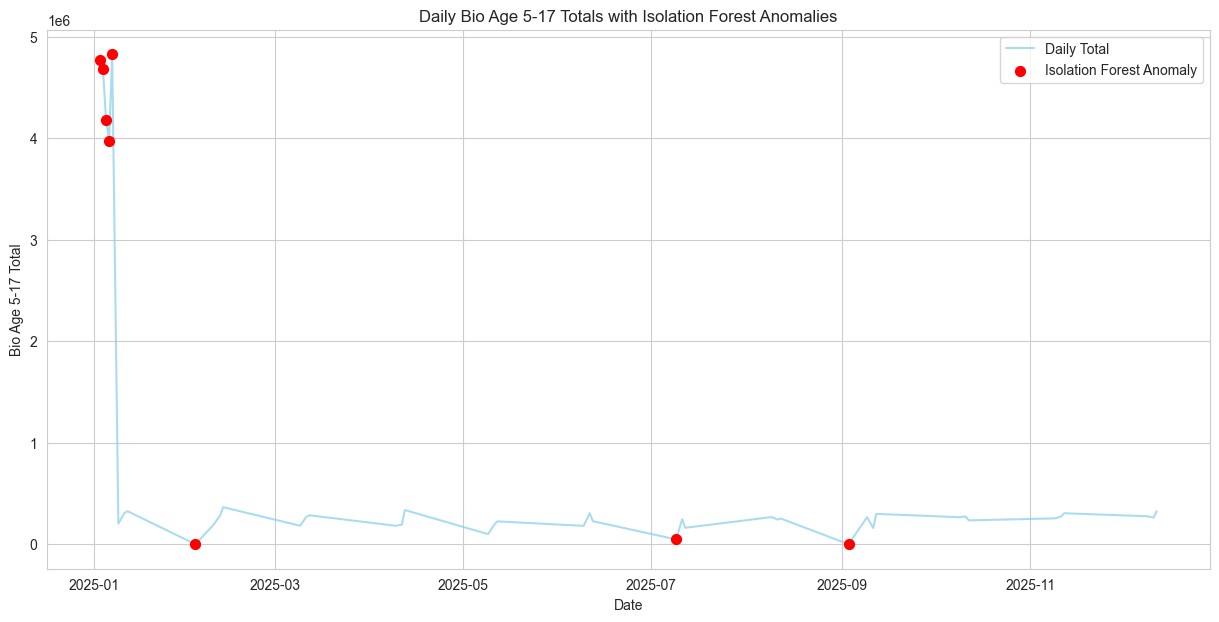

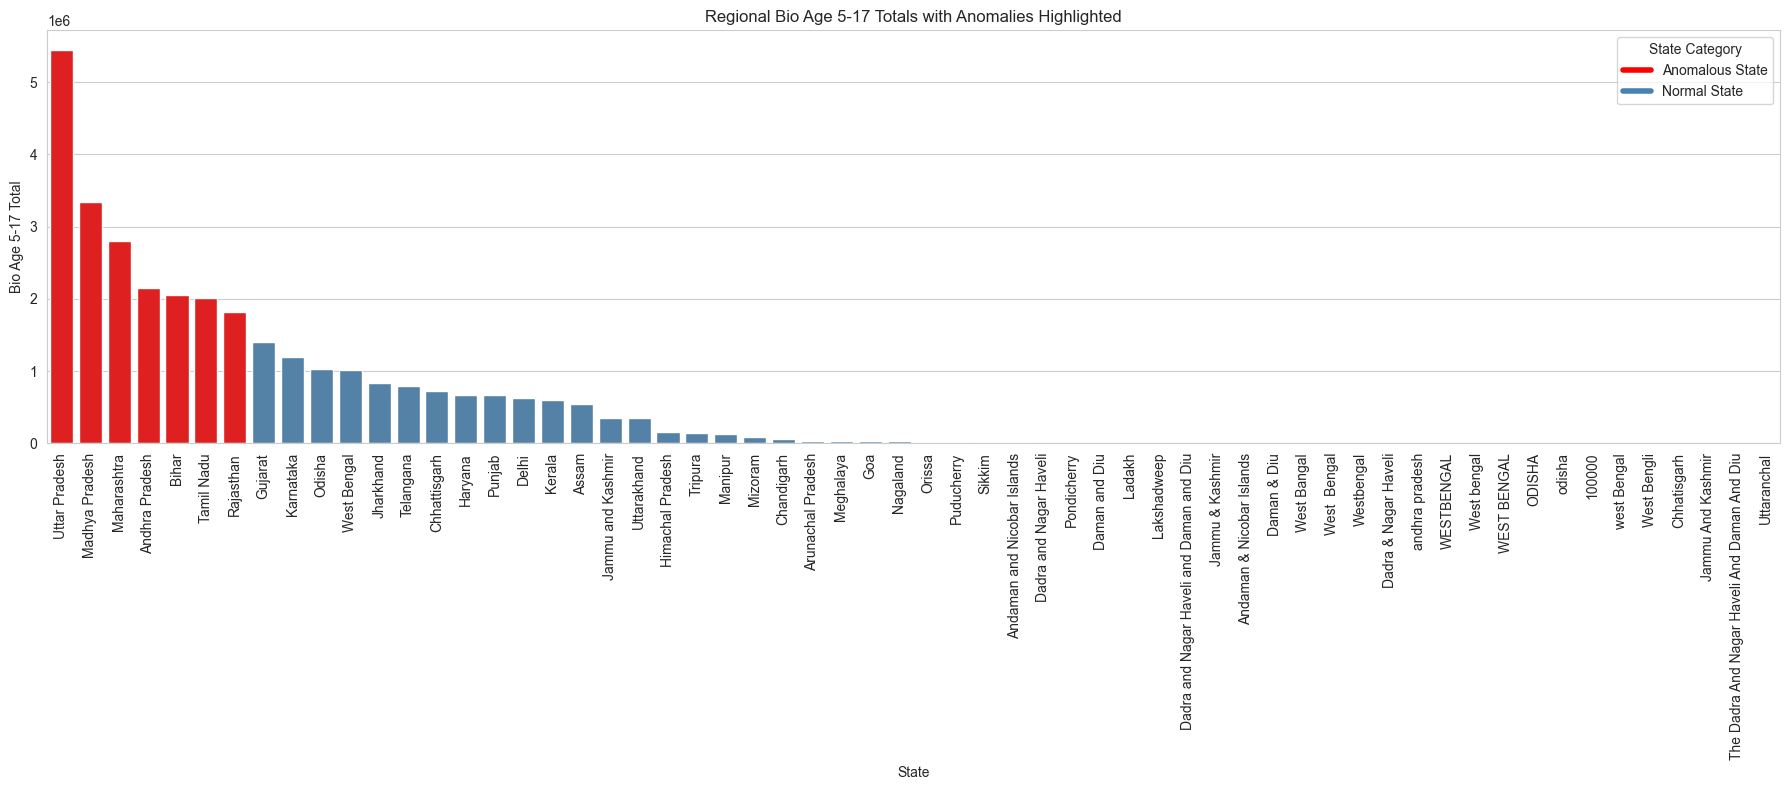

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# 1. Time-series plot for daily bio_age_5_17 totals with Isolation Forest Anomalies
plt.figure(figsize=(15, 7))
plt.plot(df_daily_totals['date'], df_daily_totals['bio_age_5_17'], label='Daily Total', color='skyblue', alpha=0.7)

# Highlight Isolation Forest anomalies
iso_forest_anomalies_bio = df_daily_totals[df_daily_totals['anomaly_label_iso_forest'] == -1]
plt.scatter(iso_forest_anomalies_bio['date'], iso_forest_anomalies_bio['bio_age_5_17'], color='red', s=50, label='Isolation Forest Anomaly', zorder=5)

plt.title('Daily Bio Age 5-17 Totals with Isolation Forest Anomalies')
plt.xlabel('Date')
plt.ylabel('Bio Age 5-17 Total')
plt.legend()
plt.grid(True)


# 2. Bar chart for regional bio_age_5_17 totals with anomalies highlighted
plt.figure(figsize=(18, 8))

# Get lists of anomalous states
zscore_anomalous_states = zscore_regional_anomalies['bio_age_5_17']['state'].tolist()
iqr_anomalous_states = iqr_regional_anomalies['bio_age_5_17']['state'].tolist()

# Combine and get unique anomalous states
all_anomalous_states = list(set(zscore_anomalous_states + iqr_anomalous_states))

# Sort for better visualization if needed, or keep original order
df_regional_totals_sorted = df_regional_totals.sort_values(by='bio_age_5_17', ascending=False)

# Create a dictionary mapping state to color
state_color_map = {state: 'red' if state in all_anomalous_states else 'steelblue' for state in df_regional_totals_sorted['state']}

sns.barplot(x='state', y='bio_age_5_17', data=df_regional_totals_sorted, hue='state', palette=state_color_map, legend=False)

plt.title('Regional Bio Age 5-17 Totals with Anomalies Highlighted')
plt.xlabel('State')
plt.ylabel('Bio Age 5-17 Total')
plt.xticks(rotation=90) # Rotate x-axis labels for readability

# Create a custom legend for colors
handles = [plt.Line2D([0], [0], color='red', lw=4), plt.Line2D([0], [0], color='steelblue', lw=4)]
labels = ['Anomalous State', 'Normal State']
plt.legend(handles, labels, title='State Category')

plt.tight_layout()
plt.show()